# Assigment 2

Numpy and Pandas

# Assigment 2 - Numpy Section

## 1.1. Create a random 1D array (lenght 5) using Numpy and print shape, dtype and second value.

## 1.2. Create a random 10x10 matrix using Numpy and print shape, dtype.

## 1.3. Calculate the matrix's total mean, sum, minimum, and maximum.

## 1.4. Calculate the matrix's **first row** mean, sum, minimum, and maximum.

## 1.5. Simulate 100 dice rolls and count how many times each number was rolled.

Hint: Create the simulation using np.random.randint(). Count occurrences with np.bincount().

In [ ]:

import numpy as np

In [4]:
# 1.1

arr = np.random.randint(0,100,size=5)

print(arr.shape, arr.dtype, arr[1])

(5,) int64 65


In [6]:
# 1.2

mat = np.random.randint(0,100,size=(10,10))
print(mat.shape, mat.dtype)

print(mat)

(10, 10) int64
[[98 29  1 56 98 40 91 24 70 37]
 [54 41 87 48 92 62 59 16 55 82]
 [56 77 21 33 69 80 41  7 96 53]
 [82 74 40  9 95 83  5 34 21  2]
 [69 47 73 95 63 95 29 91 69 14]
 [41 70 35 99 51 23 44 39  7 50]
 [62 25  9 26 27 12  3 88 94 18]
 [74 63 81 58 48 49 98 89 62 37]
 [10  3 59 16 45 63  8 32 34 68]
 [72 65 56 52 22 87 15 54 59 63]]


In [8]:
# 1.3

mean = np.mean(mat)
print("Matrix's mean value is", mean)

sum = np.sum(mat)
print("Matrix's sum is ", sum)

min = np.min(mat)
print("Matrix's minimum value is ", min)

max = np.max(mat)
print("Matrix's maximum value is ", max)

Matrix's mean value is 51.28
Matrix's sum is  5128
Matrix's minimum value is  1
Matrix's maximum value is  99


In [10]:
# 1.4

firstMean = np.mean(mat[0])
print("Matrix's first row mean value is", firstMean)

firstSum = np.sum(mat[0])
print("Matrix's first row sum is ", firstSum)

firstMin = np.min(mat[0])
print("Matrix's first row minimum value is ", firstMin)

firstMax = np.max(mat[0])
print("Matrix's firt row maximum value is ", firstMax)

Matrix's first row mean value is 54.4
Matrix's first row sum is  544
Matrix's first row minimum value is  1
Matrix's firt row maximum value is  98


In [12]:
# 1.5

rolls =np.random.randint(0,6,size=100)
counts = np.bincount(rolls)
print("The dice rolled:")
for i, count in enumerate(counts, start=1):     # start=1 makes face numbers 1–6
    print(f"Number {i} appeared {count} times")

The dice rolled:
Number 1 appeared 23 times
Number 2 appeared 16 times
Number 3 appeared 13 times
Number 4 appeared 12 times
Number 5 appeared 23 times
Number 6 appeared 13 times


# Assigment 2 - Pandas Section - Wildlife Accidents

## 2.1. Determine in which month the highest number of wildlife accidents occur. Is there a difference between months?

Group the data by month and count the number of accidents. Print also with the results sorted descending. Also comment on the results.

## 2.2. Create a cross-tabulation table showing how wildlife accidents are distributed across species and regions.

Using the wildlife accidents DataFrame (riista_df), create a cross-tabulation where rows represent wildlife species (riistalajiNimi), columns represent regions (maakuntaNimi).

## 2.3. Convert the "eventTime" column to Pandas datetime format and analyze which hours of day are the most dangerous for wildlife accidents.

Hint: Create additional columns for the day of the week and the hour of day using the pd.to_datetime() function

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import os
from chardet import detect

def get_encoding_type(file):
    with open(file, 'rb') as f:
        rawdata = f.read()
    return detect(rawdata)['encoding']
file = './koeti_riista_tau_001_fi.csv'
df = csv = pd.read_csv(file, encoding=get_encoding_type(file))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63942 entries, 0 to 63941
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               63942 non-null  int64  
 1   tapahtumaAika    63942 non-null  str    
 2   vuosi            63942 non-null  int64  
 3   kuukausi         63942 non-null  int64  
 4   x                63938 non-null  float64
 5   y                63938 non-null  float64
 6   kunta            63942 non-null  int64  
 7   kuntaNimi        63942 non-null  str    
 8   maakunta         63942 non-null  int64  
 9   maakuntaNimi     63942 non-null  str    
 10  tielaji          63942 non-null  int64  
 11  tielajis         63942 non-null  str    
 12  tieNumero        54512 non-null  float64
 13  tieYllapito      63938 non-null  float64
 14  tieYllapitoNimi  63942 non-null  str    
 15  riistalaji       63942 non-null  int64  
 16  riistalajiNimi   63942 non-null  str    
dtypes: float64(4), int64(7)

kuukausi
11    10962
10     8467
12     6382
5      6301
9      5995
6      5551
7      4516
8      4450
1      4110
4      3007
2      2194
3      2007
Name: count, dtype: int64


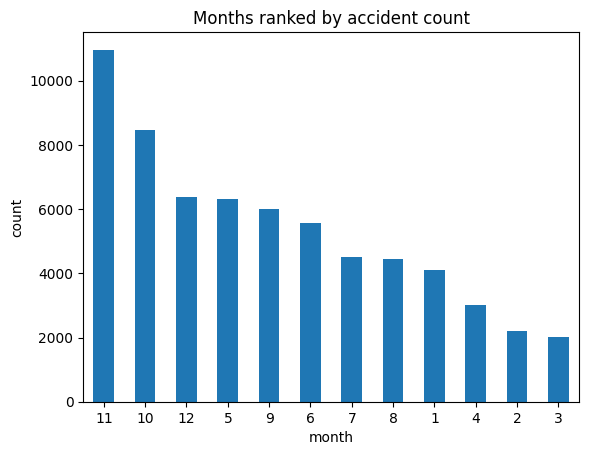

In [16]:
# 2.1

accidents_by_months = df['kuukausi'].value_counts()
accidents_by_months.plot(kind='bar', title='Months ranked by accident count', xlabel='month', ylabel='count',)
plt.xticks(rotation=0)

print(accidents_by_months)




By this data the most accident prone month is november.




<Axes: title={'center': 'animal species by region'}, xlabel='species', ylabel='region'>

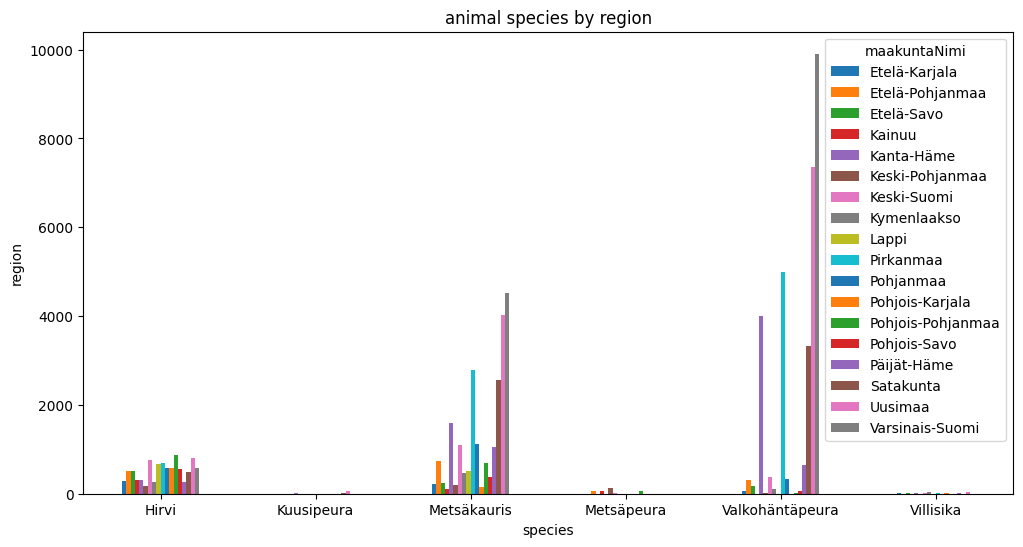

In [18]:
# 2.2

species = df['riistalajiNimi']
regions = df['maakuntaNimi']

crosstab = pd.crosstab(species, regions)

crosstab.plot(
        kind='bar',
        figsize=(12,6),
        title='animal species by region',
        xlabel='species', ylabel='region',
        rot=0
        )





<Axes: title={'center': 'Accidents on hour of day'}, xlabel='weekday', ylabel='hour'>

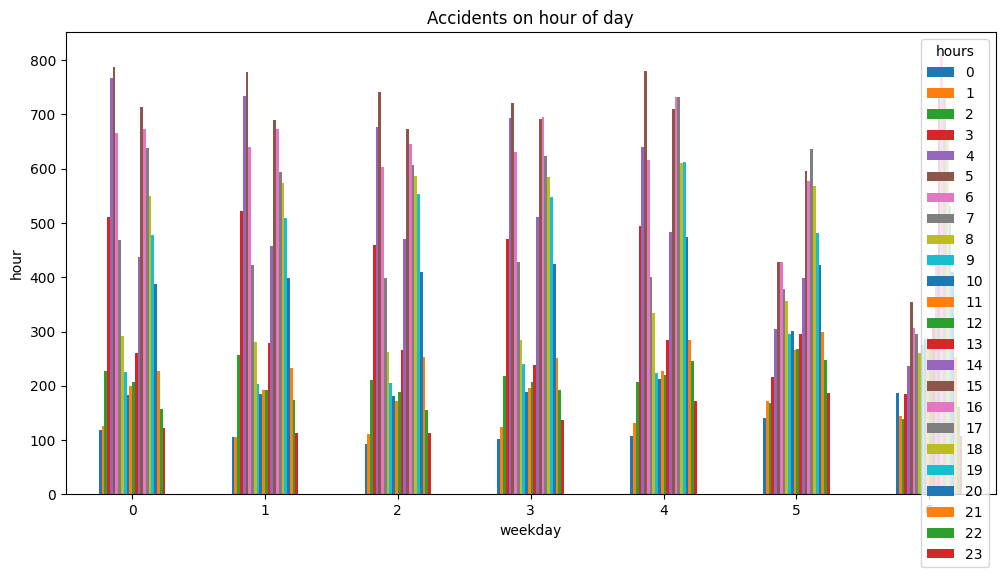

In [19]:
# 2.3


# ## 2.3. convert the "eventtime" column to pandas datetime format and analyze which hours of day are the most dangerous for wildlife accidents.
#
# hint: create additional columns for the day of the week and the hour of day using the pd.to_datetime() function
eventTime= pd.to_datetime(df['tapahtumaAika'],utc=True)

eventTime.head(5)

df['weekday'] = eventTime.dt.weekday
df['hours'] = eventTime.dt.hour


hourOfDay = pd.crosstab(df['weekday'], df['hours'])

hourOfDay.plot(
        kind='bar', 
        figsize=(12,6),
        title='Accidents on hour of day',
        xlabel='weekday',
        ylabel='hour',
        rot=0
        )


 most dangerous time of day is in early morning


